In [13]:
import mysql.connector
from credenciales import mysql_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import plotly.express as px
import plotly.io as pio
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import IsolationForest

In [14]:
#Creación del nuevo dataframe.
conn = mysql.connector.connect(**mysql_config)

---
## Extracción del dataset analítico

In [15]:
query = """
SELECT
    e.Cultivo,
    e.Provincia,
    e.Anio,
    e.Hectareas,
    a.Temp_media,
    a.Temp_min,
    a.Temp_max,
    a.Precipitacion,
    f.Area,
    f.Producto,
    f.Elemento,
    f.Valor,
    n.PRECTOTCORR,
    n.T2M,
    n.T2M_MAX,
    n.T2M_MIN
FROM ESYRCE e
JOIN AEMET a 
    ON e.Anio = a.anio
    AND (
        (e.Provincia = 'VALLADOLID' AND a.Provincia = 'Valladolid') OR
        (e.Provincia = 'LA RIOJA'   AND a.Provincia = 'Logroño') OR
        (e.Provincia = 'JAEN'       AND a.Provincia = 'Jaén') OR
        (e.Provincia = 'VALENCIA'   AND a.Provincia = 'Valencia')
    )
JOIN NASA n ON e.Anio = n.YEAR
JOIN FAOSTAT f ON e.Anio = f.Anio
WHERE e.Provincia IN ('VALLADOLID', 'LA RIOJA', 'JAEN', 'VALENCIA')
"""

df_agric_clima = pd.read_sql(query, conn)
conn.close()

df_agric_clima.head()

/var/folders/gk/7whljmd13_gckymc1r2zhl800000gn/T/ipykernel_1869/2013901619.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_agric_clima = pd.read_sql(query, conn)


,Cultivo,Provincia,Anio,Hectareas,Temp_media,Temp_min,Temp_max,Precipitacion,Area,Producto,Elemento,Valor,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN
0,PATATA,LA RIOJA,2005,1674.3593,13.368767,8.215069,18.527672,351.2,España,"Aceite de colza, en bruto",Producción,6300.0,0.9,13.34,39.85,-8.9
1,PATATA,JAEN,2005,135.7973,22.616411,14.104102,31.127693,191.3,España,"Aceite de colza, en bruto",Producción,6300.0,0.9,13.34,39.85,-8.9
2,OTROS TUBERCULOS PARA CO,VALENCIA,2005,0.7292,18.004383,13.515890,22.491234,345.2,España,"Aceite de colza, en bruto",Producción,6300.0,0.9,13.34,39.85,-8.9
3,CHUFA,VALENCIA,2005,479.5104,18.004383,13.515890,22.491234,345.2,España,"Aceite de colza, en bruto",Producción,6300.0,0.9,13.34,39.85,-8.9
4,BATATA,VALLADOLID,2005,NaN,12.833698,6.624383,19.038904,275.8,España,"Aceite de colza, en bruto",Producción,6300.0,0.9,13.34,39.85,-8.9


In [16]:
df_agric_clima.to_parquet('dataset_analitico_parquet')
df_agric_clima = pd.read_parquet('dataset_analitico_parquet')

---
## EDA

In [17]:
#Reorganización de columnas para que tengan un orden más lógico
df_agric_clima = df_agric_clima[[
    "Area", "Anio", "Provincia", "Elemento","Producto", "Cultivo", 
    "Hectareas", "Valor", "Temp_media", "Temp_min", "Temp_max",
    "Precipitacion", "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"
]]

df_agric_clima.head()

,Area,Anio,Provincia,Elemento,Producto,Cultivo,Hectareas,Valor,Temp_media,Temp_min,Temp_max,Precipitacion,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN
0,España,2005,LA RIOJA,Producción,"Aceite de colza, en bruto",PATATA,1674.3593,6300.0,13.368767,8.215069,18.527672,351.2,0.9,13.34,39.85,-8.9
1,España,2005,JAEN,Producción,"Aceite de colza, en bruto",PATATA,135.7973,6300.0,22.616411,14.104102,31.127693,191.3,0.9,13.34,39.85,-8.9
2,España,2005,VALENCIA,Producción,"Aceite de colza, en bruto",OTROS TUBERCULOS PARA CO,0.7292,6300.0,18.004383,13.515890,22.491234,345.2,0.9,13.34,39.85,-8.9
3,España,2005,VALENCIA,Producción,"Aceite de colza, en bruto",CHUFA,479.5104,6300.0,18.004383,13.515890,22.491234,345.2,0.9,13.34,39.85,-8.9
4,España,2005,VALLADOLID,Producción,"Aceite de colza, en bruto",BATATA,NaN,6300.0,12.833698,6.624383,19.038904,275.8,0.9,13.34,39.85,-8.9


In [18]:
#Exploración del dataframe analítico.
df_agric_clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 2704032 entries, 0 to 2704031
Data columns (total 16 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Area           str    
 1   Anio           int64  
 2   Provincia      str    
 3   Elemento       str    
 4   Producto       str    
 5   Cultivo        str    
 6   Hectareas      float64
 7   Valor          float64
 8   Temp_media     float64
 9   Temp_min       float64
 10  Temp_max       float64
 11  Precipitacion  float64
 12  PRECTOTCORR    float64
 13  T2M            float64
 14  T2M_MAX        float64
 15  T2M_MIN        float64
dtypes: float64(10), int64(1), str(5)
memory usage: 482.4 MB


In [19]:
#Hay casi un 1,5 millones de filas. 
#Agrupo los cultivos que me interesan, ya que revisarlos todos sería demasiado extenso para un primer análisis.

cultivos_esyrce = [
    "TRIGO DURO", "TRIGO BLANDO Y SEMIDURO", "CEBADA DE 2 CARRERAS", 
    "CEBADA DE 6 CARRERAS", "AVENA", "MAIZ", "TRITICALE",
    "ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA",
    "UVA DE MESA NO ESPECIFIC", "UVA DE TRANSFORMACION",
    "NARANJO", "MANDARINO", "LIMONERO", "NARANJO AMARGO"
]

productos_faostat = [
    "Trigo", "Maíz", "Triticale",
    "Aceitunas, olivas",
    "Uvas",
    "Naranjas", "Limones y limas", "Tangerinas, mandarinas, clementinas"
]

df_agric_clima_filtrado = df_agric_clima[
    (df_agric_clima["Cultivo"].isin(cultivos_esyrce)) &
    (df_agric_clima["Producto"].isin(productos_faostat))
]

print(len(df_agric_clima_filtrado))

24480


In [20]:
#Guardo el df filtrado, con un número de filas más adecuado.
df_agric_clima = df_agric_clima_filtrado.copy()
df_agric_clima.to_parquet('dataset_analitico_filtrado.parquet')
print(df_agric_clima.shape)

(24480, 16)


In [21]:
#Nueva exploración de datos tras el filtro.
df_agric_clima.info()

<class 'pandas.DataFrame'>
Index: 24480 entries, 384368 to 2704022
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           24480 non-null  str    
 1   Anio           24480 non-null  int64  
 2   Provincia      24480 non-null  str    
 3   Elemento       24480 non-null  str    
 4   Producto       24480 non-null  str    
 5   Cultivo        24480 non-null  str    
 6   Hectareas      20352 non-null  float64
 7   Valor          24480 non-null  float64
 8   Temp_media     24480 non-null  float64
 9   Temp_min       24480 non-null  float64
 10  Temp_max       24480 non-null  float64
 11  Precipitacion  24480 non-null  float64
 12  PRECTOTCORR    24480 non-null  float64
 13  T2M            24480 non-null  float64
 14  T2M_MAX        24480 non-null  float64
 15  T2M_MIN        24480 non-null  float64
dtypes: float64(10), int64(1), str(5)
memory usage: 4.5 MB


In [22]:
#Revisión de nulos
(df_agric_clima.isnull().sum()/len(df_agric_clima))*100

Area              0.000000
Anio              0.000000
Provincia         0.000000
Elemento          0.000000
Producto          0.000000
Cultivo           0.000000
Hectareas        16.862745
Valor             0.000000
Temp_media        0.000000
Temp_min          0.000000
Temp_max          0.000000
Precipitacion     0.000000
PRECTOTCORR       0.000000
T2M               0.000000
T2M_MAX           0.000000
T2M_MIN           0.000000
dtype: float64

#### **Distribuciones**

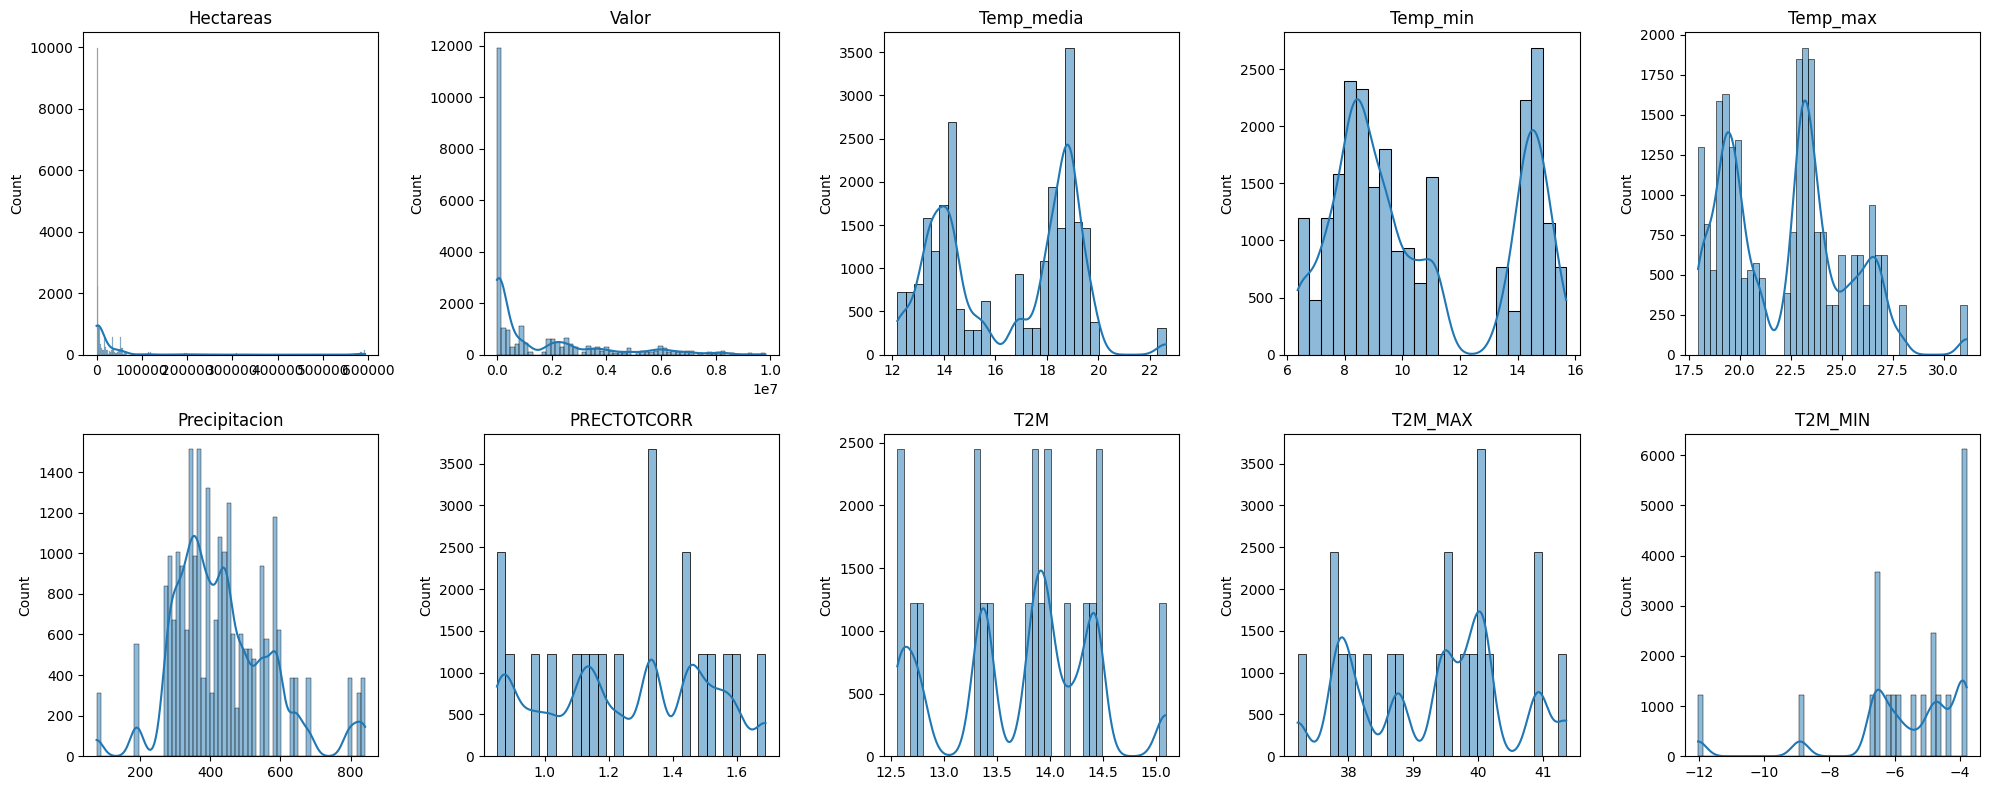

In [23]:
numericas = ["Hectareas", "Valor", "Temp_media", "Temp_min", "Temp_max", 
             "Precipitacion", "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.histplot(df_agric_clima[col].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

##### **Hectáreas y Valor**

Ambas variables presentan una distribución exponencial con cola larga hacia la derecha, típica de datos agrícolas donde unas pocas combinaciones de cultivo y provincia concentran la mayor parte de la superficie cultivada y la producción. Se observan valores extremos en el extremo derecho que serán analizados como posibles outliers.

##### **Temperaturas (Temp_media, Temp_min, Temp_max)**
Las tres variables muestran una distribución multimodal con cuatro grupos diferenciados, coherente con los distintos perfiles climáticos de las provincias analizadas: Jaén (más cálida), Valencia, Valladolid y La Rioja (más fría).

##### **Precipitación (AEMET)**
Distribución dispersa con alta variabilidad, reflejo de los patrones de precipitación muy distintos entre las cuatro provincias.

##### **Variables NASA (PRECTOTCORR, T2M, T2M_MAX, T2M_MIN)**
Muestran picos muy definidos y regulares, reflejo de su naturaleza como datos anuales nacionales que se repiten para cada combinación de cultivo y provincia dentro del mismo año.

In [24]:
estadisticos = pd.DataFrame({
    "Skewness": df_agric_clima[numericas].skew(),
    "Kurtosis": df_agric_clima[numericas].kurtosis()
})

print(estadisticos)

               Skewness   Kurtosis
Hectareas      4.993912  25.478045
Valor          1.584958   1.625751
Temp_media    -0.067929  -1.368257
Temp_min       0.389010  -1.382831
Temp_max       0.397879  -0.475772
Precipitacion  0.688656   0.883289
PRECTOTCORR   -0.070245  -1.153137
T2M           -0.170763  -0.695473
T2M_MAX       -0.078613  -1.008916
T2M_MIN       -1.747248   3.265854


#### **Skewness y Kurtosis**

**Hectáreas** presenta un skewness de 4.99 y kurtosis de 25.5, distribución muy sesgada a la derecha con una cantidad extraordinaria de outliers. Es candidata prioritaria a transformación logarítmica antes del modelado.

**Valor** muestra sesgo positivo moderado (1.58) con colas relativamente normales (1.63).

**Temperaturas (AEMET)** presentan sesgos bajos y kurtosis negativa, coherente con su distribución multimodal entre los cuatro grupos climáticos.

**Precipitación (AEMET)** presenta sesgo positivo moderado (0.69), dentro del umbral aceptable.

**Variables NASA** es la variable más problemática con kurtosis 3.27 y sesgo negativo fuerte (-1.75), con colas pesadas y valores extremos hacia temperaturas mínimas muy bajas.

#### **Q-Q Plot**
Al estar trabajando con una muestra grande,n > 5000, considero más fiable el uso de este método.

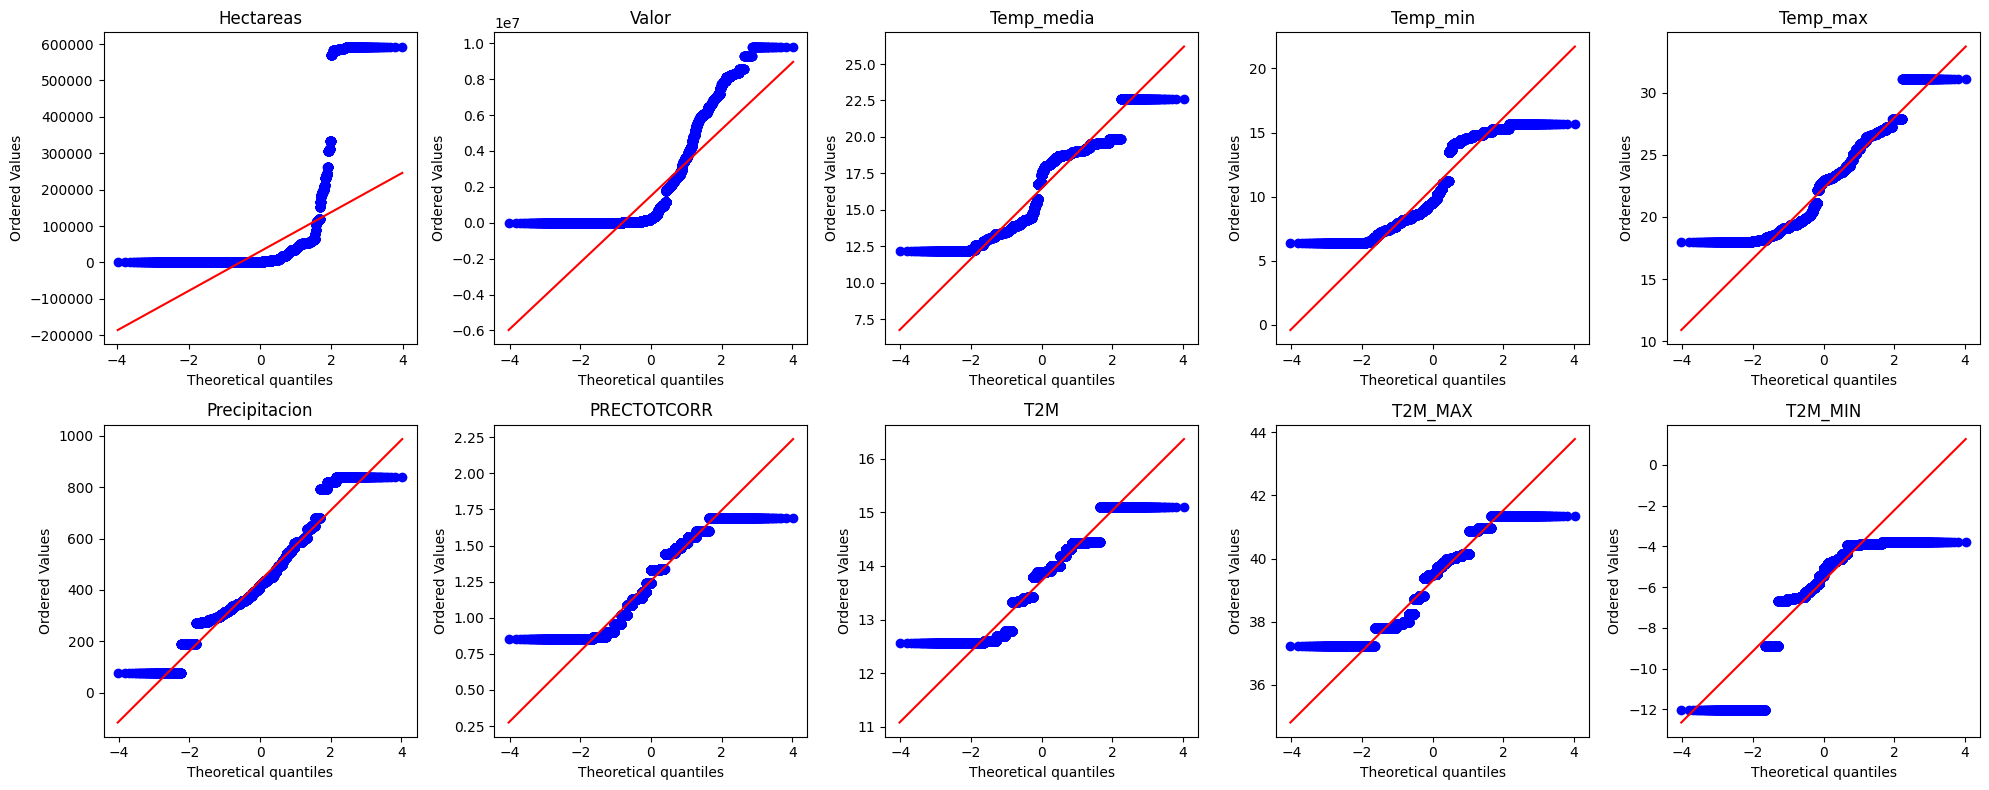

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    datos = df_agric_clima[col].dropna()
    stats.probplot(datos, dist="norm", plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Ninguna variable sigue una distribución normal. Se observan tres patrones principales:

**Hectáreas y Valor** presentan una S muy pronunciada con la cola superior muy alejada de la línea teórica, confirmando el sesgo positivo extremo detectado en el skewness y la kurtosis. Ambas variables son candidatas a transformación antes del modelado.

**Temperaturas AEMET** muestran una S con escalones que corresponden a los cuatro grupos climáticos identificados: Jaén, Valencia, Valladolid y La Rioja. Con cuatro provincias la curva es más suave que con dos, aproximándose más a la línea teórica en la zona central, especialmente en Temp_max.

**Precipitación** es la más próxima a la línea en la zona central pero con los extremos desviados, reflejo de la alta variabilidad entre las cuatro provincias.

**Variables NASA** presentan escalones horizontales muy marcados, reflejo de que son pocos valores distintos (uno por año) repetidos para cada combinación de cultivo y provincia.

#### **Transformación de datos.**

#### Yeo-Johnson.

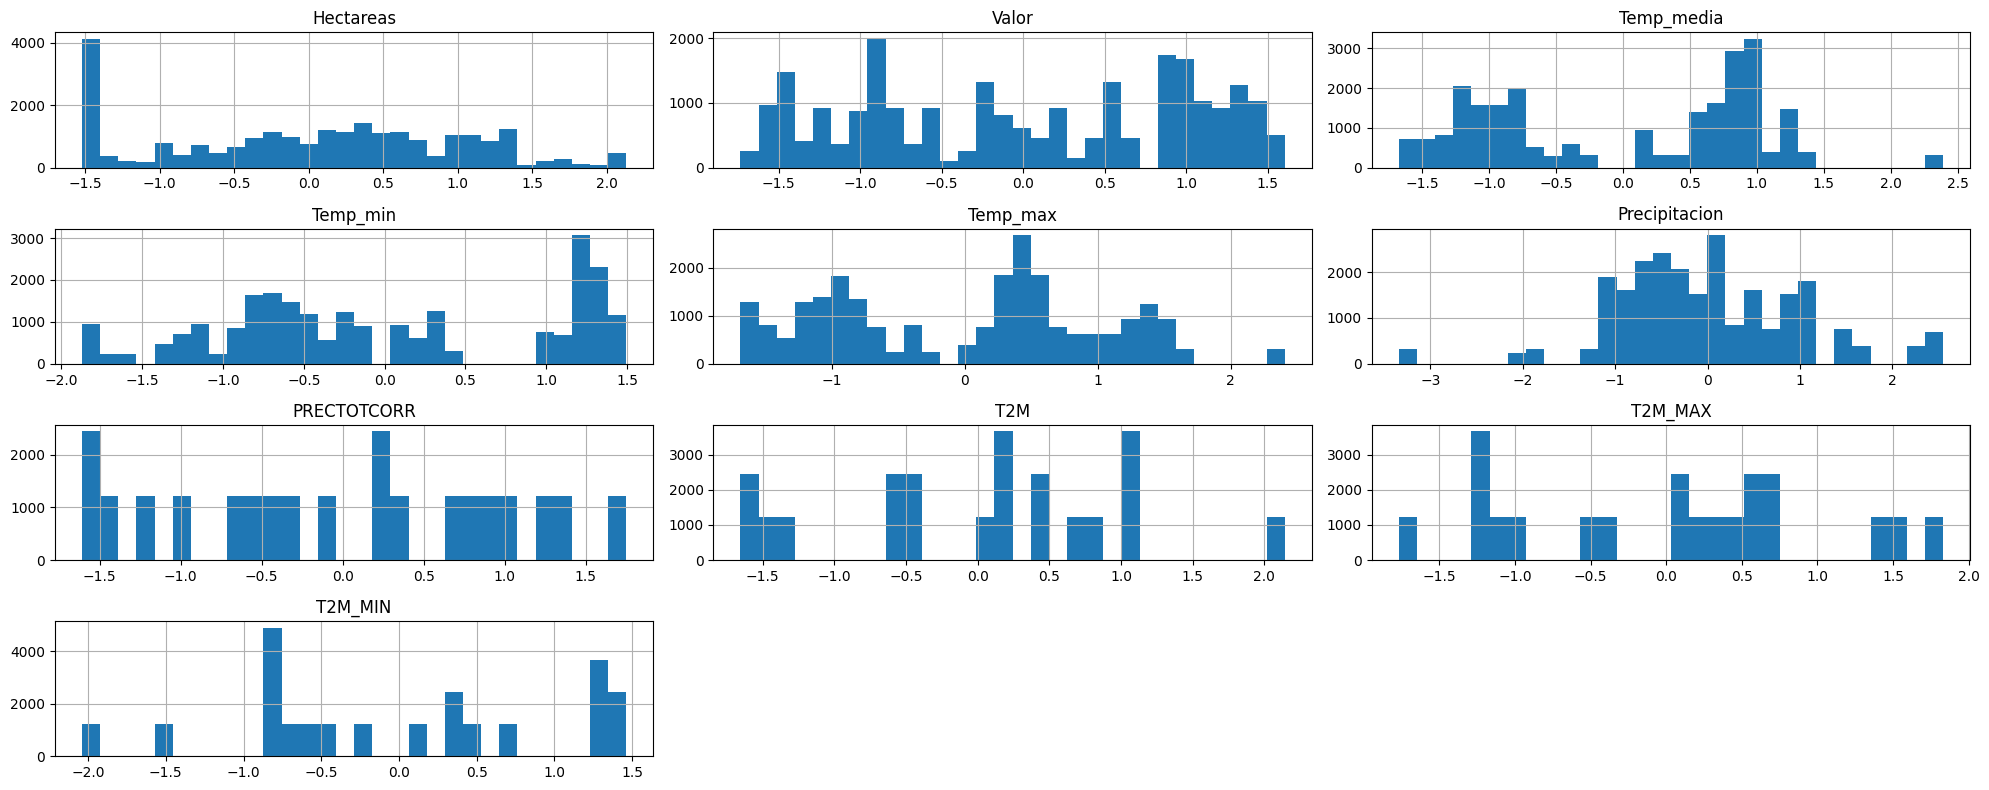

In [26]:
pt = PowerTransformer(method='yeo-johnson')

df_transformado = df_agric_clima.copy()
df_transformado[numericas] = pt.fit_transform(df_agric_clima[numericas].fillna(0))

df_transformado[numericas].hist(figsize=(20, 8), bins=30)
plt.tight_layout()
plt.show()

In [27]:
pd.DataFrame({
    "Skewness_original": df_agric_clima[numericas].skew(),
    "Skewness_transformado": df_transformado[numericas].skew(),
    "Kurtosis_original": df_agric_clima[numericas].kurtosis(),
    "Kurtosis_transformado": df_transformado[numericas].kurtosis()
}).round(3)

,Skewness_original,Skewness_transformado,Kurtosis_original,Kurtosis_transformado
Hectareas,4.994,-0.061,25.478,-0.948
Valor,1.585,-0.072,1.626,-1.399
Temp_media,-0.068,-0.070,-1.368,-1.370
Temp_min,0.389,0.054,-1.383,-1.252
Temp_max,0.398,0.032,-0.476,-1.048
Precipitacion,0.689,0.089,0.883,1.076
PRECTOTCORR,-0.070,-0.050,-1.153,-1.153
T2M,-0.171,-0.027,-0.695,-0.607
T2M_MAX,-0.079,-0.022,-1.009,-0.993
T2M_MIN,-1.747,-0.120,3.266,-0.936


Se aplicó la transformación Yeo-Johnson a todas las variables numéricas para reducir el sesgo y aproximar las distribuciones a la normalidad.

#### Resultados destacados

- **Hectáreas**: skewness de 4.99 → -0.06 y kurtosis de 25.5 → -0.95. La transformación más espectacular, era la variable más problemática.
- **Valor**: skewness de 1.59 → -0.07. Prácticamente simétrica tras la transformación.
- **T2M_MIN**: skewness de -1.75 → -0.12 y kurtosis de 3.27 → -0.94. 
La variable climática más problemática quedó muy bien resuelta.
- **Precipitación**: skewness de 0.69 → 0.09. Resultado casi perfecto.
- **Temp_min y Temp_max**: mejoran notablemente al tener 4 provincias con perfiles climáticos más equilibrados.

### Limitaciones
Las temperaturas AEMET mantienen una kurtosis negativa elevada porque su naturaleza multimodal, derivada de los cuatro grupos climáticos distintos (Jaén, Valencia, Valladolid y La Rioja), no puede corregirse completamente con transformaciones matemáticas.

#### **Outliers**

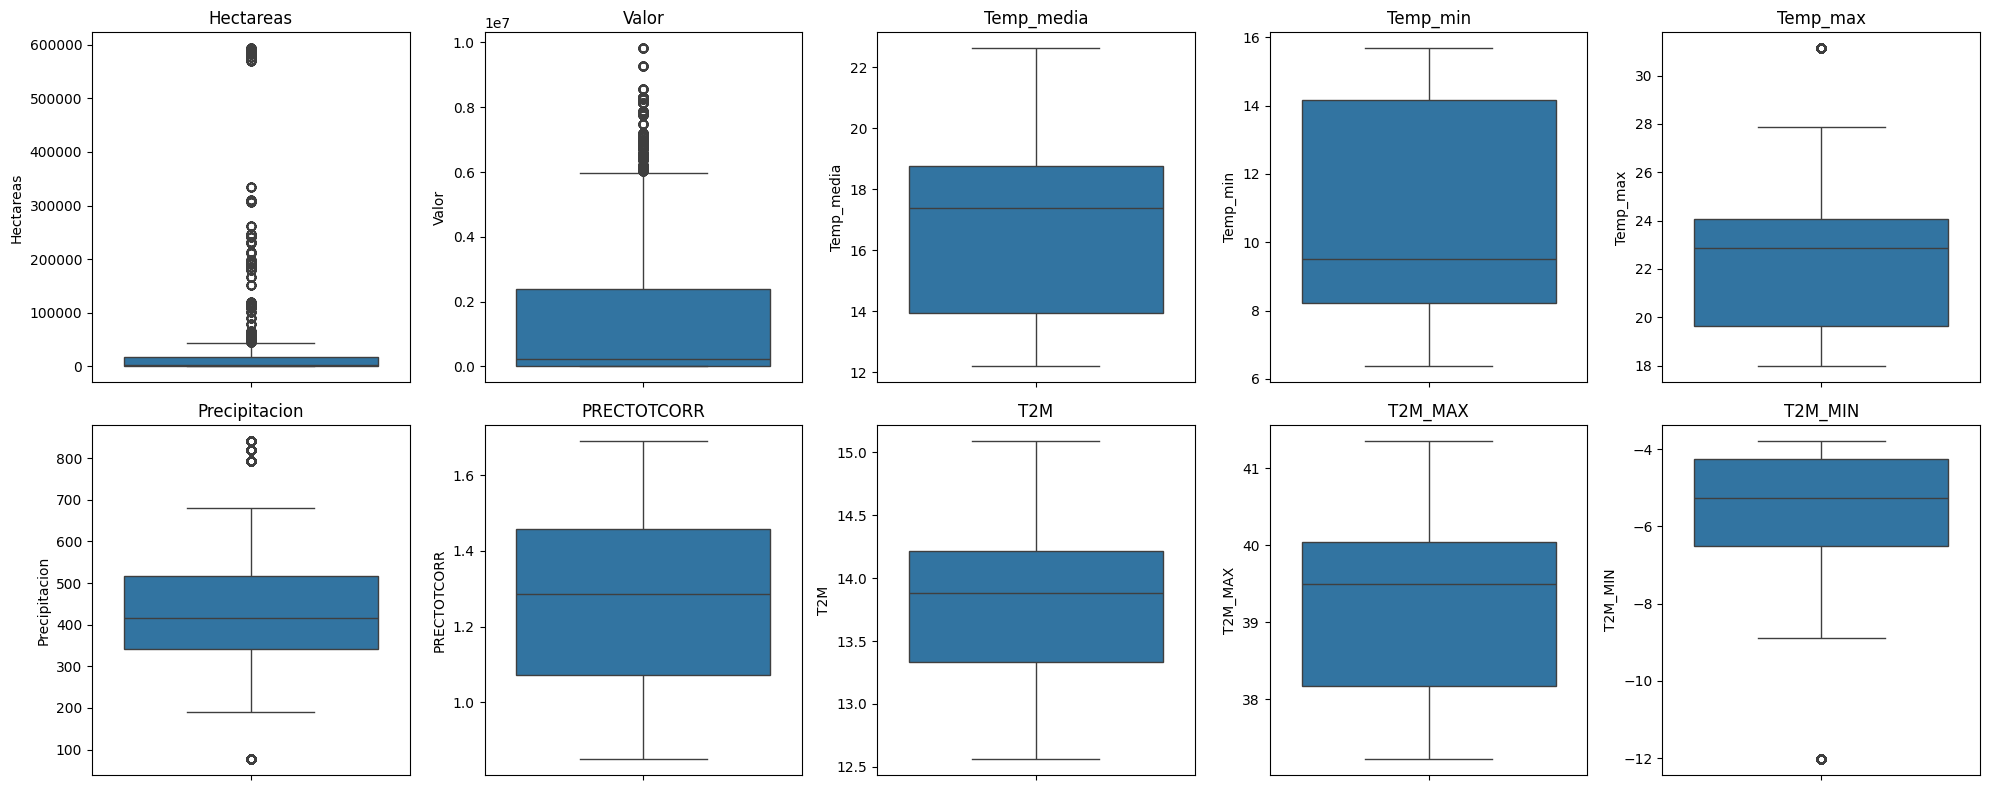

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(data=df_agric_clima, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Los boxplots revelan patrones consistentes con el análisis previo:

- **Hectáreas y Valor**  presentan numerosos outliers en la parte superior, correspondientes a cultivos o provincias con superficies y producciones muy por encima de la media.
- **Temperaturas AEMET**  muestran muy pocos outliers. Con 4 provincias la caja es más amplia y abarca mejor la variabilidad climática. Temp_max muestra un único punto outlier superior correspondiente a Jaén.
- **Precipitación** muestra algunos outliers en ambos extremos, reflejo de años 
excepcionalmente secos o lluviosos en alguna de las provincias.
- **Variables NASA** sin outliers destacables al tener pocos valores únicos.
- **T2M_MIN** mantiene un punto outlier hacia temperaturas mínimas extremas.

In [29]:
iso = IsolationForest(contamination=0.05, random_state=42)

df_agric_clima["outlier"] = iso.fit_predict(df_agric_clima[numericas].fillna(0))

# -1 = outlier, 1 = normal
print(df_agric_clima["outlier"].value_counts())

outlier
 1    23257
-1     1223
Name: count, dtype: int64


Se aplicó Isolation Forest con un umbral de contaminación del 5%, detectando 
1.224 observaciones atípicas sobre 24.480 filas totales, proporcional al dataset 
anterior al haber duplicado las filas con la incorporación de Jaén y La Rioja.

Se decidió **mantener los outliers** en el dataset sin eliminarlos, ya que 
corresponden a valores agrícolas reales y no a errores de medición.

#### **Evolución temporal**

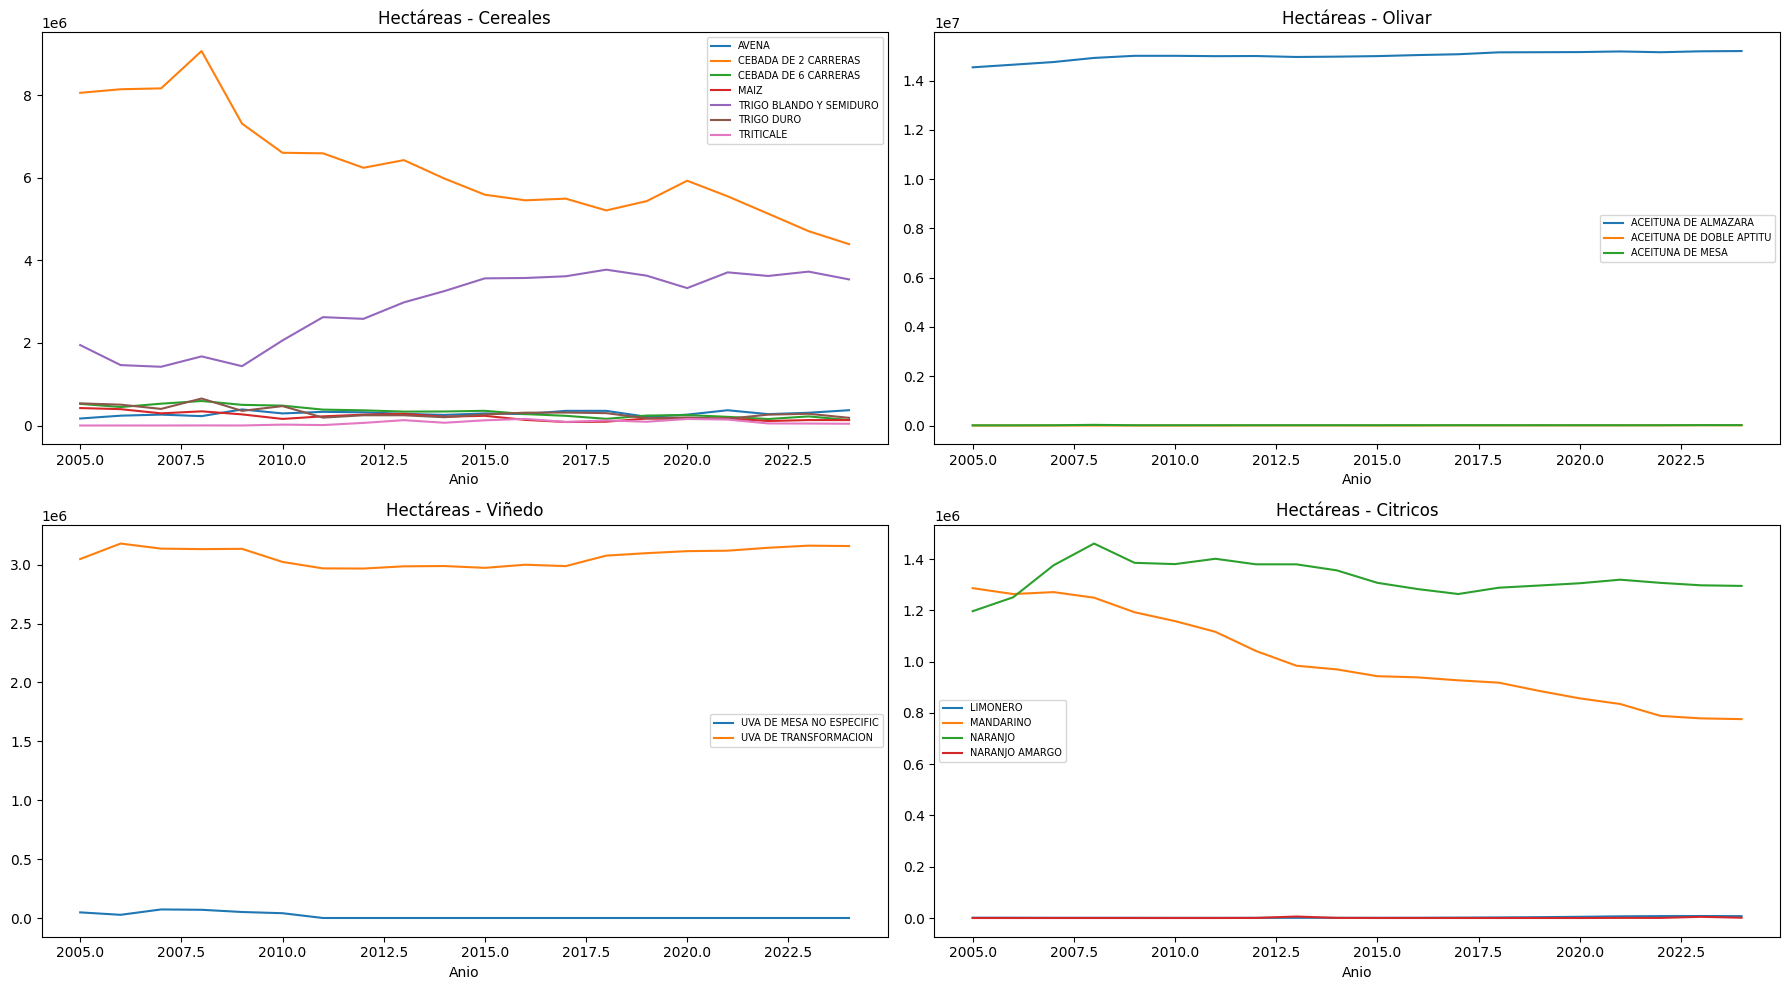

In [30]:
#Graficas de cultivos (ha)
grupos = {
    "Cereales": ["TRIGO DURO", "TRIGO BLANDO Y SEMIDURO", "CEBADA DE 2 CARRERAS", 
                 "CEBADA DE 6 CARRERAS", "AVENA", "MAIZ", "TRITICALE"],
    "Olivar": ["ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA"],
    "Viñedo": ["UVA DE MESA NO ESPECIFIC", "UVA DE TRANSFORMACION"],
    "Citricos": ["NARANJO", "MANDARINO", "LIMONERO", "NARANJO AMARGO"]
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, (grupo, cultivos) in enumerate(grupos.items()):
    df_agric_clima[df_agric_clima["Cultivo"].isin(cultivos)]\
        .groupby(["Anio", "Cultivo"])["Hectareas"].sum().unstack()\
        .plot(ax=axes[i], title=f"Hectáreas - {grupo}")
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

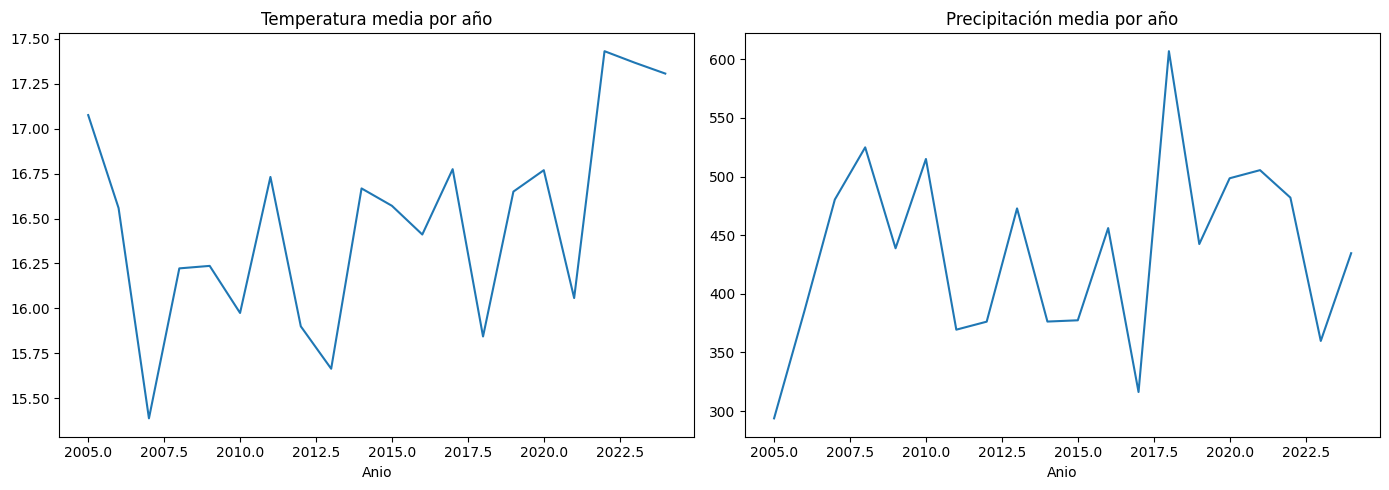

In [31]:
#Gráficas de temperaturas y precipitaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_agric_clima.groupby("Anio")["Temp_media"].mean().plot(
    ax=axes[0], title="Temperatura media por año"
)

df_agric_clima.groupby("Anio")["Precipitacion"].mean().plot(
    ax=axes[1], title="Precipitación media por año"
)

plt.tight_layout()
plt.show()

##### Cereales.
La cebada de 2 carreras domina en superficie pero muestra una caída pronunciada desde 2008, perdiendo casi la mitad de sus hectáreas en el período analizado. El trigo blando y semiduro gana terreno a partir de 2012 con una tendencia alcista sostenida. El resto de cereales se mantienen estables y con superficies mucho menores.

##### Olivar.
la aceituna de almazara domina de forma abrumadora con una superficie muy superior al resto, manteniéndose estable a lo largo de todo el período. La aceituna de doble aptitud y de mesa tienen una presencia marginal.

##### Viñedo.
la uva de transformación concentra prácticamente toda la superficie, con una tendencia estable a lo largo del período. La uva de mesa tiene una presencia casi testimonial.

##### Cítricos.
El naranjo es el cultivo dominante con tendencia ligeramente estable. El mandarino muestra una caída pronunciada a lo largo del período. Limonero y Naranjo amargo tienen superficies marginales.

#### **Correlaciones**

In [32]:
#Correlación clima - hectárea
clima_vars = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion", 
              "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

correlaciones_hectareas = df_agric_clima[clima_vars + ["Hectareas"]].corr()["Hectareas"].drop("Hectareas").sort_values()

print(correlaciones_hectareas)

Temp_min        -0.079074
Precipitacion   -0.038571
T2M_MAX         -0.014997
T2M             -0.014119
PRECTOTCORR     -0.005876
T2M_MIN         -0.005459
Temp_media       0.005131
Temp_max         0.090597
Name: Hectareas, dtype: float64


In [33]:
#Correlación clima - valor
correlaciones_valor = df_agric_clima[clima_vars + ["Valor"]].corr()["Valor"].drop("Valor").sort_values()

print(correlaciones_valor)

T2M             -0.014669
Temp_max        -0.008344
Temp_media      -0.005990
T2M_MIN         -0.004439
Temp_min        -0.002203
T2M_MAX         -0.002022
Precipitacion    0.024611
PRECTOTCORR      0.030253
Name: Valor, dtype: float64


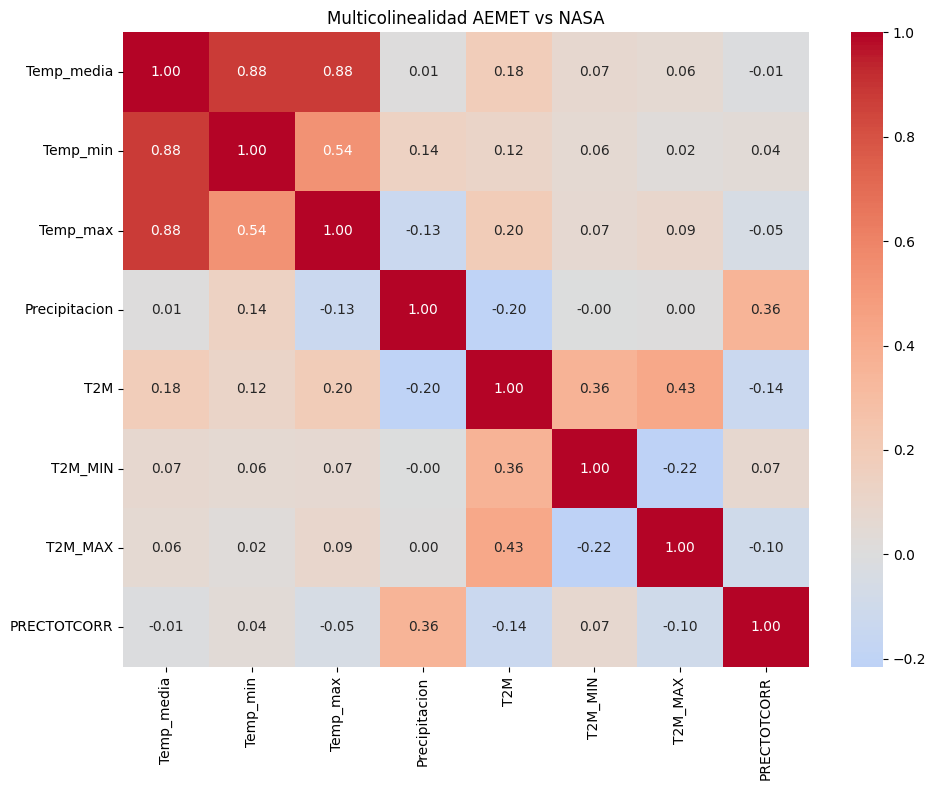

In [34]:
#Correlación medidas AEMET y NASA
aemet_vars = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion"]
nasa_vars = ["T2M", "T2M_MIN", "T2M_MAX", "PRECTOTCORR"]

correlaciones_fuentes = df_agric_clima[aemet_vars + nasa_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlaciones_fuentes,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Multicolinealidad AEMET vs NASA")
plt.tight_layout()
plt.show()

In [35]:
correlacion_hect_valor = df_agric_clima[["Hectareas", "Valor"]].corr()
print(correlacion_hect_valor)

           Hectareas     Valor
Hectareas   1.000000 -0.000522
Valor      -0.000522  1.000000


#### **1. Clima → Hectáreas**
Las correlaciones son muy débiles en general. Temp_max es la única variable con correlación positiva (0.09), sugiriendo que temperaturas máximas más altas se asocian ligeramente con mayor superficie cultivada. Temp_min muestra la correlación negativa más alta (-0.08). El resto de variables climáticas tienen correlaciones prácticamente nulas, lo que indica que el clima por sí solo explica muy poco de la variación en hectáreas a nivel agregado.

#### **2. Clima → Valor**
Correlaciones prácticamente nulas con el valor de producción. La precipitación (AEMET y NASA) muestra las correlaciones más altas aunque muy bajas (0.02-0.03). Esto se explica por la diferencia de escala: el valor de FAOSTAT es nacional mientras que el clima de AEMET es provincial, diluyendo cualquier relación lineal.

#### 3. **Multicolinealidad AEMET vs NASA**
Las temperaturas de AEMET entre sí presentan correlaciones altas (Temp_media con Temp_min y Temp_max: 0.88), aunque menores que con 2 provincias, gracias a la mayor variabilidad climática de las 4 provincias. Siguen siendo moderadamente redundantes, especialmente para modelos de regresión lineal.

#### 4. **Hectáreas → Valor**
Correlación nula (-0.0005), consecuencia de que ambas variables operan a escalas geográficas distintas (provincial vs nacional).